Author: Sreyo Biswas

In [1]:
import random
import matplotlib.pyplot as plt
import min_heap
from final_project_part1 import *
import time

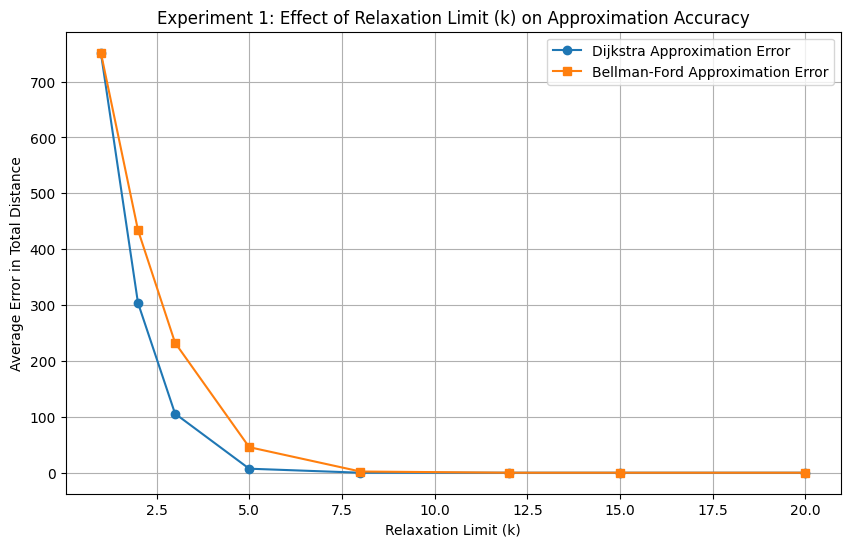

In [2]:
#Experiment 1: How does the Relaxation Limit (k) affect the accuracy of Approx Shortest Path Algorithms?
num_nodes = 100
runs = 20
max_weight = 20
k_vals = [1, 2, 3, 5, 8, 12, 15, 20]

dijkstra_approx_errors = []
bellman_ford_approx_errors = []

for k in k_vals:
    dijkstra_total_error = 0
    bellman_ford_total_error = 0
    for _ in range(runs):
        G = create_random_complete_graph(num_nodes, max_weight)
        exact_dist = total_dist(dijkstra(G, 0))
        dijkstra_total_error += total_dist(dijkstra_approx(G, 0, k)) - exact_dist
        bellman_ford_total_error += total_dist(bellman_ford_approx(G, 0, k)) - exact_dist
    dijkstra_approx_errors.append(dijkstra_total_error / runs)
    bellman_ford_approx_errors.append(bellman_ford_total_error / runs)

plt.figure(figsize=(10, 6))
plt.plot(k_vals, dijkstra_approx_errors, marker='o', label='Dijkstra Approximation Error')
plt.plot(k_vals, bellman_ford_approx_errors, marker='s', label='Bellman-Ford Approximation Error')
plt.xlabel('Relaxation Limit (k)')
plt.ylabel('Average Error in Total Distance')
plt.title('Experiment 1: Effect of Relaxation Limit (k) on Approximation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

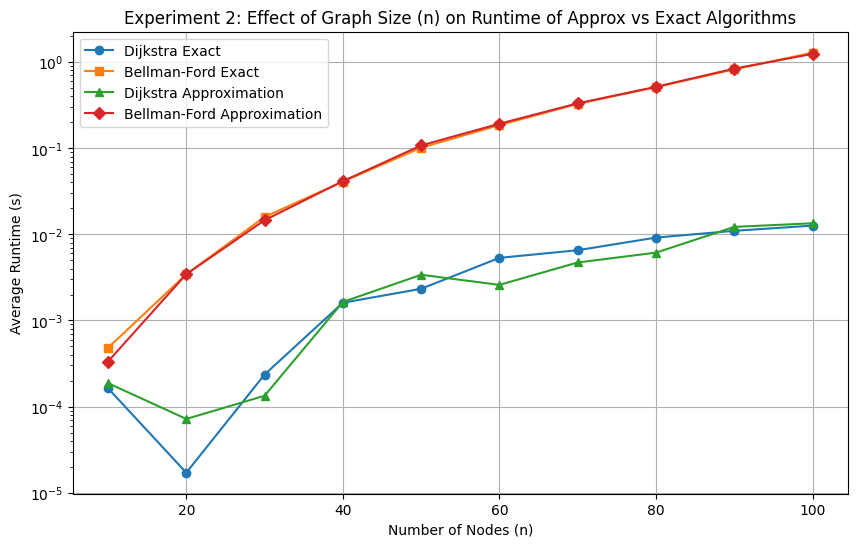

In [5]:
#Experiment 2: How does Graph Size/Number of Nodes (n) affect the runtime of Approx Shortest Path Algorithms vs Exact Algorithms?
runs = 30
max_weight = 20
k = 5
n = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

dijkstra_exact_times = []
bellman_ford_exact_times = []
dijkstra_approx_times = []
bellman_ford_approx_times = []

for num_nodes in n:
    dijkstra_exact_time = 0
    bellman_ford_exact_time = 0
    dijkstra_approx_time = 0
    bellman_ford_approx_time = 0
    for _ in range(runs):
        G = create_random_complete_graph(num_nodes, max_weight)
        
        start = time.time()
        dijkstra(G, 0)
        dijkstra_exact_time += time.time() - start
        
        start = time.time()
        bellman_ford(G, 0)
        bellman_ford_exact_time += time.time() - start
        
        start = time.time()
        dijkstra_approx(G, 0, k)
        dijkstra_approx_time += time.time() - start
        
        start = time.time()
        bellman_ford_approx(G, 0, k)
        bellman_ford_approx_time += time.time() - start

    dijkstra_exact_times.append(dijkstra_exact_time / runs)
    bellman_ford_exact_times.append(bellman_ford_exact_time / runs)
    dijkstra_approx_times.append(dijkstra_approx_time / runs)
    bellman_ford_approx_times.append(bellman_ford_approx_time / runs)

plt.figure(figsize=(10, 6))
plt.plot(n, dijkstra_exact_times, marker='o', label='Dijkstra Exact')
plt.plot(n, bellman_ford_exact_times, marker='s', label='Bellman-Ford Exact')
plt.plot(n, dijkstra_approx_times, marker='^', label='Dijkstra Approximation')
plt.plot(n, bellman_ford_approx_times, marker='D', label='Bellman-Ford Approximation')
plt.xlabel('Number of Nodes (n)')
plt.ylabel('Average Runtime (s)')
plt.title('Experiment 2: Effect of Graph Size (n) on Runtime of Approx vs Exact Algorithms')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

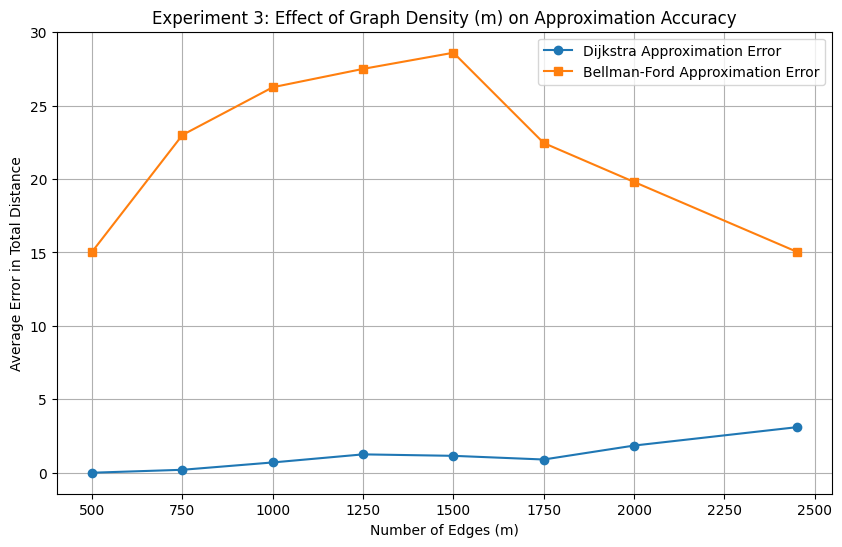

In [6]:
# Experiment 3: Effect of Graph Density (m) on Approximation Error of Shortest Path Algorithms
n = 50
num_trials = 20
max_weight = 20
k = 5
max_edges = n * (n - 1)
m_vals = [500, 750, 1000, 1250, 1500, 1750, 2000, max_edges]

dijkstra_approx_errors = []
bellman_ford_approx_errors = []

for m in m_vals:
    dijkstra_approx_error = 0
    bellman_ford_approx_error = 0
    for _ in range(num_trials):
        G = create_random_graph(n, m, max_weight)
        
        exact_results = dijkstra(G, 0)
        d_approx_results = dijkstra_approx(G, 0, k)
        bf_approx_results = bellman_ford_approx(G, 0, k)
        
        for i in range(n):
            #need to account for unreachable nodes (inf distance) when calculating error
            if exact_results[i] != float('inf'):
                if d_approx_results[i] != float('inf'):
                    dijkstra_approx_error += (d_approx_results[i] - exact_results[i])
                
                if bf_approx_results[i] != float('inf'):
                    bellman_ford_approx_error += (bf_approx_results[i] - exact_results[i])
                    
    dijkstra_approx_errors.append(dijkstra_approx_error / num_trials)
    bellman_ford_approx_errors.append(bellman_ford_approx_error / num_trials)

plt.figure(figsize=(10, 6))
plt.plot(m_vals, dijkstra_approx_errors, marker='o', label='Dijkstra Approximation Error')
plt.plot(m_vals, bellman_ford_approx_errors, marker='s', label='Bellman-Ford Approximation Error')
plt.xlabel('Number of Edges (m)')
plt.ylabel('Average Error in Total Distance')
plt.title('Experiment 3: Effect of Graph Density (m) on Approximation Accuracy')
plt.legend()
plt.grid(True)
plt.show()